Chapter 27
# 一元OLS线性回归
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

0.5 * x_data + 1真实线性关系：y = 0.5x + 1（斜率0.5，截距1）

np.random.normal(0, 1, num)噪声项：从标准正态分布（均值0，标准差1）中采样50个随机数

整体在真实值上叠加随机噪声，模拟现实数据中的随机误差

1. 标准差是正态分布的"标尺"
正态分布的形状完全由 均值（μ） 和 标准差（σ） 决定：

均值 μ：决定分布的中心位置（对称轴）

标准差 σ：决定分布的"胖瘦"（离散程度）

text
σ 越大 → 数据越分散 → 曲线越"矮胖"

σ 越小 → 数据越集中 → 曲线越"高瘦"

In [2]:
# 生成随机数据
num = 50
np.random.seed(0) # 种子
x_data = np.random.uniform(0,10,num) # 从均匀分布中随机抽取 50 (0-10)个数值生成50个数据
y_data = 0.5 * x_data + 1 + np.random.normal(0, 1, num)
data = np.column_stack([x_data,y_data]) # 按照列进行堆叠；就是两列；也就是每一行就是一个点

In [3]:
x_data

array([5.48813504, 7.15189366, 6.02763376, 5.44883183, 4.23654799,
       6.45894113, 4.37587211, 8.91773001, 9.63662761, 3.83441519,
       7.91725038, 5.2889492 , 5.68044561, 9.25596638, 0.71036058,
       0.871293  , 0.20218397, 8.32619846, 7.78156751, 8.70012148,
       9.78618342, 7.99158564, 4.61479362, 7.80529176, 1.18274426,
       6.39921021, 1.43353287, 9.44668917, 5.21848322, 4.1466194 ,
       2.64555612, 7.74233689, 4.56150332, 5.68433949, 0.187898  ,
       6.17635497, 6.12095723, 6.16933997, 9.43748079, 6.81820299,
       3.59507901, 4.37031954, 6.97631196, 0.60225472, 6.66766715,
       6.7063787 , 2.10382561, 1.28926298, 3.15428351, 3.63710771])

In [4]:
y_data

array([ 2.03779733,  6.52672223,  3.5041647 ,  3.28634161,  1.86547864,
        5.00696092,  1.57403821,  5.24612472,  4.92284724,  3.30411009,
        4.44782005,  2.46384241,  3.81204058,  6.05631506,  1.42169751,
        1.7381184 ,  0.46676989,  4.80035806,  4.21832331,  4.99050758,
        5.07994543,  3.26951022,  3.48482295,  4.50086495, -0.03882622,
        4.66238736,  0.80946807,  5.77528998,  4.33833217,  3.20229261,
        3.46217875,  3.63634263,  3.6830933 ,  3.15735965,  0.22315185,
        3.50932782,  3.74892608,  4.14083533,  4.55359055,  5.30992798,
        3.26320194,  1.64891608,  5.97640817,  3.19701653,  5.51261315,
        4.17326451,  0.98116018,  2.69908322,  2.17396481,  4.04099893])

In [5]:
data

array([[ 5.48813504,  2.03779733],
       [ 7.15189366,  6.52672223],
       [ 6.02763376,  3.5041647 ],
       [ 5.44883183,  3.28634161],
       [ 4.23654799,  1.86547864],
       [ 6.45894113,  5.00696092],
       [ 4.37587211,  1.57403821],
       [ 8.91773001,  5.24612472],
       [ 9.63662761,  4.92284724],
       [ 3.83441519,  3.30411009],
       [ 7.91725038,  4.44782005],
       [ 5.2889492 ,  2.46384241],
       [ 5.68044561,  3.81204058],
       [ 9.25596638,  6.05631506],
       [ 0.71036058,  1.42169751],
       [ 0.871293  ,  1.7381184 ],
       [ 0.20218397,  0.46676989],
       [ 8.32619846,  4.80035806],
       [ 7.78156751,  4.21832331],
       [ 8.70012148,  4.99050758],
       [ 9.78618342,  5.07994543],
       [ 7.99158564,  3.26951022],
       [ 4.61479362,  3.48482295],
       [ 7.80529176,  4.50086495],
       [ 1.18274426, -0.03882622],
       [ 6.39921021,  4.66238736],
       [ 1.43353287,  0.80946807],
       [ 9.44668917,  5.77528998],
       [ 5.21848322,

 sm.add_constant(x_data) 是 statsmodels 中的一个函数，用于在矩阵或数组x_data 的左侧添加全 1 常数列，目的是为了计算截距项。

In [6]:
# 添加常数列
X = sm.add_constant(x_data)

In [7]:
X

array([[1.        , 5.48813504],
       [1.        , 7.15189366],
       [1.        , 6.02763376],
       [1.        , 5.44883183],
       [1.        , 4.23654799],
       [1.        , 6.45894113],
       [1.        , 4.37587211],
       [1.        , 8.91773001],
       [1.        , 9.63662761],
       [1.        , 3.83441519],
       [1.        , 7.91725038],
       [1.        , 5.2889492 ],
       [1.        , 5.68044561],
       [1.        , 9.25596638],
       [1.        , 0.71036058],
       [1.        , 0.871293  ],
       [1.        , 0.20218397],
       [1.        , 8.32619846],
       [1.        , 7.78156751],
       [1.        , 8.70012148],
       [1.        , 9.78618342],
       [1.        , 7.99158564],
       [1.        , 4.61479362],
       [1.        , 7.80529176],
       [1.        , 1.18274426],
       [1.        , 6.39921021],
       [1.        , 1.43353287],
       [1.        , 9.44668917],
       [1.        , 5.21848322],
       [1.        , 4.1466194 ],
       [1.

In [8]:
# 创建一元OLS线性回归模型
model = sm.OLS(y_data, X)

In [9]:
model

调用 fit() 方法来对模型进行拟合，从而得到对应的回归系数和其他相关统计信息。


In [10]:
# 拟合模型
results = model.fit()

results.params 保存线性回归结果，
results.params[1] 为斜率 (slope) b1，

results.params[0] 为截距 (intercept) b0。
一元线性回归的解析式为 y = b1x + b0

##线性回归结果

In [13]:
results.params # 也就是 截距与斜率

array([0.99278992, 0.46927329])

###截距

In [14]:
results.params[0]

np.float64(0.9927899158697228)

###斜率

In [15]:
results.params[1]

np.float64(0.4692732947309526)

###打印回归结果

In [11]:
# 打印回归结果
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     91.59
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.05e-12
Time:                        10:49:02   Log-Likelihood:                -67.046
No. Observations:                  50   AIC:                             138.1
Df Residuals:                      48   BIC:                             141.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9928      0.296      3.358      0.0

In [17]:
# 预测
x_array = np.linspace(0,10,101) # 生成一系列的点
predicted = results.params[1] * x_array + results.params[0] # 将数据点带入函数求出y值

In [18]:
predicted

array([0.99278992, 1.03971725, 1.08664457, 1.1335719 , 1.18049923,
       1.22742656, 1.27435389, 1.32128122, 1.36820855, 1.41513588,
       1.46206321, 1.50899054, 1.55591787, 1.6028452 , 1.64977253,
       1.69669986, 1.74362719, 1.79055452, 1.83748185, 1.88440918,
       1.93133651, 1.97826383, 2.02519116, 2.07211849, 2.11904582,
       2.16597315, 2.21290048, 2.25982781, 2.30675514, 2.35368247,
       2.4006098 , 2.44753713, 2.49446446, 2.54139179, 2.58831912,
       2.63524645, 2.68217378, 2.72910111, 2.77602844, 2.82295577,
       2.86988309, 2.91681042, 2.96373775, 3.01066508, 3.05759241,
       3.10451974, 3.15144707, 3.1983744 , 3.24530173, 3.29222906,
       3.33915639, 3.38608372, 3.43301105, 3.47993838, 3.52686571,
       3.57379304, 3.62072037, 3.6676477 , 3.71457503, 3.76150235,
       3.80842968, 3.85535701, 3.90228434, 3.94921167, 3.996139  ,
       4.04306633, 4.08999366, 4.13692099, 4.18384832, 4.23077565,
       4.27770298, 4.32463031, 4.37155764, 4.41848497, 4.46541

##绘制代码

In [19]:
results

In [20]:
results.fittedvalues  # 50个数据；拟合值

array([3.56822513, 4.34898262, 3.82139747, 3.54978118, 2.98088875,
       4.0237985 , 3.04626984, 5.17764246, 5.5150019 , 2.79217856,
       4.70814409, 3.47475253, 3.65847134, 5.33636776, 1.32614317,
       1.40166445, 1.08766946, 4.9000525 , 4.64447174, 5.07552459,
       5.58518445, 4.74302764, 3.15838932, 4.6556049 , 1.54782021,
       3.99576838, 1.66550861, 5.42586887, 3.44168473, 2.93868766,
       2.23427875, 4.62606186, 3.13338161, 3.66029864, 1.08096543,
       3.89118836, 3.86519168, 3.88789641, 5.42154762, 4.1923905 ,
       2.67986449, 3.04366416, 4.26658681, 1.27541197, 4.12174805,
       4.13991434, 1.98005909, 1.5978066 , 2.47301093, 2.69958743])

results.fittedvalues:将x_data数据带入我们求解的线性回归方程；

也就是预测的直线

(-2.0, 8.0)

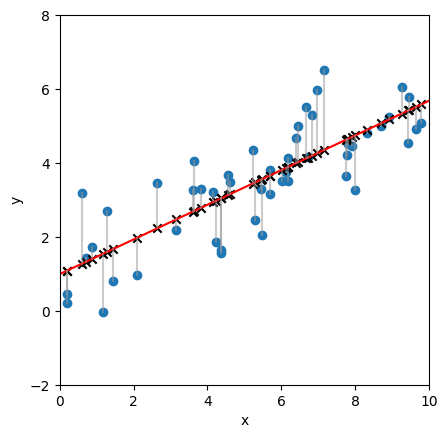

In [21]:
fig, ax = plt.subplots()
ax.scatter(x_data, y_data) # 散点图；原始数据
ax.scatter(x_data, results.fittedvalues,  # 线性回归线
           color = 'k', marker = 'x')

# 我们根据数据得出的 线性回归线
ax.plot(x_array, predicted,
        color = 'r')
# 两列堆叠；每一行就是一个点
data_ = np.column_stack([x_data,results.fittedvalues])

# 这个是；原始数据到预测数据的直线
# data = np.column_stack([x_data,y_data])
# 取出data_的x,y坐标的值（也就是预测值）； 取出data的x,y坐标的值（也就是原始数据）
# 效果就是原始数据到线性回归线的竖直线
# 绘制样本值 ● 和预测值 × 连线线段。这个线段代表误差。

ax.plot(([i for (i,j) in data_], [i for (i,j) in data]),
        ([j for (i,j) in data_], [j for (i,j) in data]),
        c=[0.6,0.6,0.6], alpha = 0.5) # 灰色与透明度

ax.set_xlabel('x'); ax.set_ylabel('y') # 标签
ax.set_aspect('equal', adjustable='box') # x,y轴比例一致
ax.set_xlim(0,10); ax.set_ylim(-2,8) # 范围
# fig.savefig('一元线性回归.svg', format='svg')

(-2.0, 8.0)

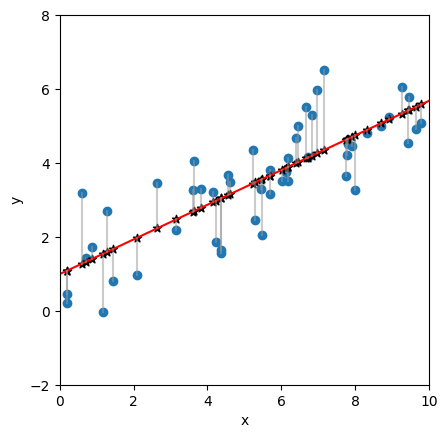

In [23]:
fig, ax = plt.subplots()
ax.scatter(x_data, y_data) # 散点图；原始数据
ax.scatter(x_data, results.fittedvalues,  # 线性回归线
           color = 'k', marker = '*')

# 我们根据数据得出的 线性回归线
ax.plot(x_array, predicted,
        color = 'r')
# 两列堆叠；每一行就是一个点
data_ = np.column_stack([x_data,results.fittedvalues])

# 这个是；原始数据到预测数据的直线
# data = np.column_stack([x_data,y_data])
# 取出data_的x,y坐标的值（也就是预测值）； 取出data的x,y坐标的值（也就是原始数据）
# 效果就是原始数据到线性回归线的竖直线
ax.plot(([i for (i,j) in data_], [i for (i,j) in data]),
        ([j for (i,j) in data_], [j for (i,j) in data]),
        c=[0.6,0.6,0.6], alpha = 0.5) # 灰色与透明度

ax.set_xlabel('x'); ax.set_ylabel('y') # 标签
ax.set_aspect('equal', adjustable='box') # x,y轴比例一致
ax.set_xlim(0,10); ax.set_ylim(-2,8) # 范围
# fig.savefig('一元线性回归.svg', format='svg')